In [1]:
import pandas as pd
from pathlib import Path
file_path = "/home/sambray/Documents/c3po/tutorial/c3po_dandi_candidate_datasets_v2.csv"
dataset_df = pd.read_csv(file_path)

dandiset_id = 774

dataset_df = dataset_df[dataset_df['dandiset_id'] == dandiset_id]

dandiset_id = f"{dandiset_id:06d}"
dandi_path = dataset_df['dandi_path'].values[0]
model_dir = Path(f"/stelmo/sam/c3po_dandi_training_v2/{dandiset_id}")

In [2]:
import matplotlib.pyplot as plt
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"  # Disable GPU usage for this example

from pathlib import Path
from dandi.dandiapi import DandiAPIClient
from dandi.consts import known_instances
import fsspec
from fsspec.implementations.cached import CachingFileSystem
import h5py
import pynwb

def get_dandi_file(dandiset_id, dandi_path, dandi_instance="dandi"):
    tmp_dir = "dandi_cache"  # Local folder for cache
    Path(tmp_dir).mkdir(exist_ok=True)  # Create the cache folder if it doesn't exist

    # get the s3 url from Dandi
    with DandiAPIClient(
        dandi_instance=known_instances[dandi_instance],
    ) as client:
        asset = client.get_dandiset(dandiset_id).get_asset_by_path(dandi_path)
        s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)

    # stream the file from s3
    # first, create a virtual filesystem based on the http protocol
    fs = fsspec.filesystem("http")

    # create a cache to save downloaded data to disk (optional)
    fsspec_file = CachingFileSystem(
        fs=fs,
        cache_storage=tmp_dir,  # Local folder for cache
    )

    # Open and return the file
    fs_file = fsspec_file.open(s3_url, "rb")
    io = pynwb.NWBHDF5IO(file=h5py.File(fs_file))
    nwbfile = io.read()
    return io, nwbfile

In [3]:
nwbfile = get_dandi_file(dandiset_id, dandi_path, dandi_instance="dandi")[1]

In [4]:
from c3po.analysis.analysis import C3poAnalysis
import numpy as np
analysis = C3poAnalysis(model_dir=model_dir)
analysis.fit_context_pca()
# t_interp = np.arange(analysis.t[0], analysis.t[-1], 0.001)
t_interp = np.arange(analysis.t[0], analysis.t[-1], 0.0001)
analysis.interpolate_context(t_interp)
analysis.embed_context_pca()

In [47]:
nwbfile

root pynwb.file.NWBFile at 0x140444632532304
Fields:
  devices: {
    NSP1 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    PPC <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  epochs: epochs <class 'pynwb.epoch.TimeIntervals'>
  experiment_description: Intracortical recordings during a brain-computer interface finger movement task
  experimenter: ['Tyson Aflalo' 'Carey Zhang']
  file_create_date: [datetime.datetime(2022, 2, 11, 9, 11, 12, 614907, tzinfo=tzoffset(None, -28800))]
  identifier: sub-P1_ses-20180910T102421
  institution: California Institute of Technology
  intervals: {
    epochs <class 'pynwb.epoch.TimeIntervals'>,
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  lab: Andersen Lab
  session_description: individual-finger press, main task
  session_id: 2018-09-10
  session_start_time: 2018-09-10 10:24:21-07:00
  subject: subject pynwb.file.Subject at 0x140444631951312
Fields:
  description: tetraplegic woman
  sex: F
  species: Human
  subject_id: P1

  timestamps_reference_time: 2018-09-10 10:24:21-07:00
  trials: trials <class 'pynwb.epoch.TimeIntervals'>
  units: units <class 'pynwb.misc.Units'>

In [5]:
obj_id = dataset_df['event_object_id'].values[0]
event_df = nwbfile.objects[obj_id].to_dataframe()
event_df#[:30]
# event_df.pulse_number.unique()

,start_time,stop_time,train_duration,train_period,train_quantity,shape,run,pulse_duration,pulse_number,event_period,amplitude,contacts,contact_negative,contact_positive,contact_negative_coords,contact_positive_coords,polarity,notes
id,,,,,,,,,,,,,,,,,,
0,1991.613600,1993.613600,1.0,2.0,75,biphasic,0,100,1,10.0,-25,16r_2b,16,2,"[8428.0, 1288.0, 3303.0]","[8428.0, 1238.0, 3303.0]",bipolar,
1,1993.615600,1995.615600,1.0,2.0,75,biphasic,0,100,1,10.0,-25,16r_2b,16,2,"[8428.0, 1288.0, 3303.0]","[8428.0, 1238.0, 3303.0]",bipolar,
2,1995.617600,1997.617600,1.0,2.0,75,biphasic,0,100,1,10.0,-25,16r_2b,16,2,"[8428.0, 1288.0, 3303.0]","[8428.0, 1238.0, 3303.0]",bipolar,
3,1997.619600,1999.619600,1.0,2.0,75,biphasic,0,100,1,10.0,-25,16r_2b,16,2,"[8428.0, 1288.0, 3303.0]","[8428.0, 1238.0, 3303.0]",bipolar,
4,1999.621600,2001.621600,1.0,2.0,75,biphasic,0,100,1,10.0,-25,16r_2b,16,2,"[8428.0, 1288.0, 3303.0]","[8428.0, 1238.0, 3303.0]",bipolar,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2695,8431.015833,8433.015833,1.0,2.0,50,biphasic,36,200,1,10.0,25,16r,16,0,"[8428.0, 1288.0, 3303.0]","[0.0, 0.0, 0.0]",monopolar,
2696,8433.017833,8435.017833,1.0,2.0,50,biphasic,36,200,1,10.0,25,16r,16,0,"[8428.0, 1288.0, 3303.0]","[0.0, 0.0, 0.0]",monopolar,
2697,8435.019833,8437.019833,1.0,2.0,50,biphasic,36,200,1,10.0,25,16r,16,0,"[8428.0, 1288.0, 3303.0]","[0.0, 0.0, 0.0]",monopolar,


In [16]:
# cp = event_df.contact_positive.values
# cn = event_df.contact_negative.values
# c_pair = [f"{p}_{n}" for p, n in zip(cp, cn)]
# event_df['contact_pair'] = c_pair
event_df.amplitude.unique()

array([ -25,   25,  -50,   50, -100,   -5,    5,  -10,   10,  100],
      dtype=int32)

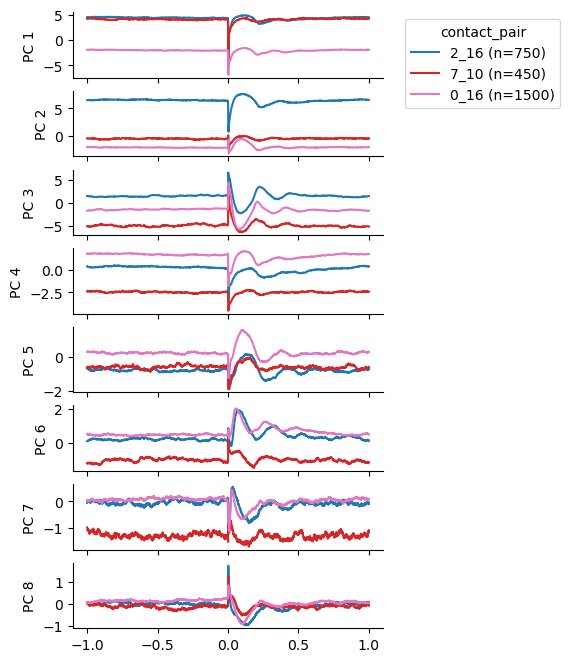

In [14]:
mark = "start_time"
feature = "contact_pair"
window = (-1,1)

fig, ax = plt.subplots(nrows = 8, sharex=True, figsize=(4,8))
feature_val_list = event_df[feature].unique()
# feature_val_list = [val for val in feature_val_list if "presentation" in val]

for i_feat, feature_val in enumerate(feature_val_list):
    df = event_df[event_df[feature] == feature_val]
    result = analysis.alligned_response(df[mark].values, window, pca=True)
    mid = np.mean(result, axis=0)
    low = np.percentile(result, 25, axis=0)
    high = np.percentile(result, 75, axis=0)
    if isinstance(feature_val, str):
        color = i_feat / len(feature_val_list)
        color = plt.cm.tab10(color)
    else:
        color = (feature_val - np.min(feature_val_list)) / (np.max(feature_val_list) - np.min(feature_val_list))
        color = plt.cm.viridis(color)
    t_plot = np.linspace(window[0], window[1], mid.shape[0])

    for i, a in enumerate(ax):
        # a.fill_between(t_plot, low[:,i], high[:,i], color=plt.cm.viridis(color), alpha=0.3)
        label = f"{feature_val} (n={len(df)})"
        a.plot(t_plot, mid[:,i], color=color, label=label)
        a.set_ylabel(f"PC {i+1}")
        a.spines[['top', 'right']].set_visible(False)
ax[0].legend(title=feature, bbox_to_anchor=(1.05, 1), loc='upper left')

In [22]:
sub_groups[0]

np.int32(-25)

Text(0.5, 0, 'Time from start_time (s)')

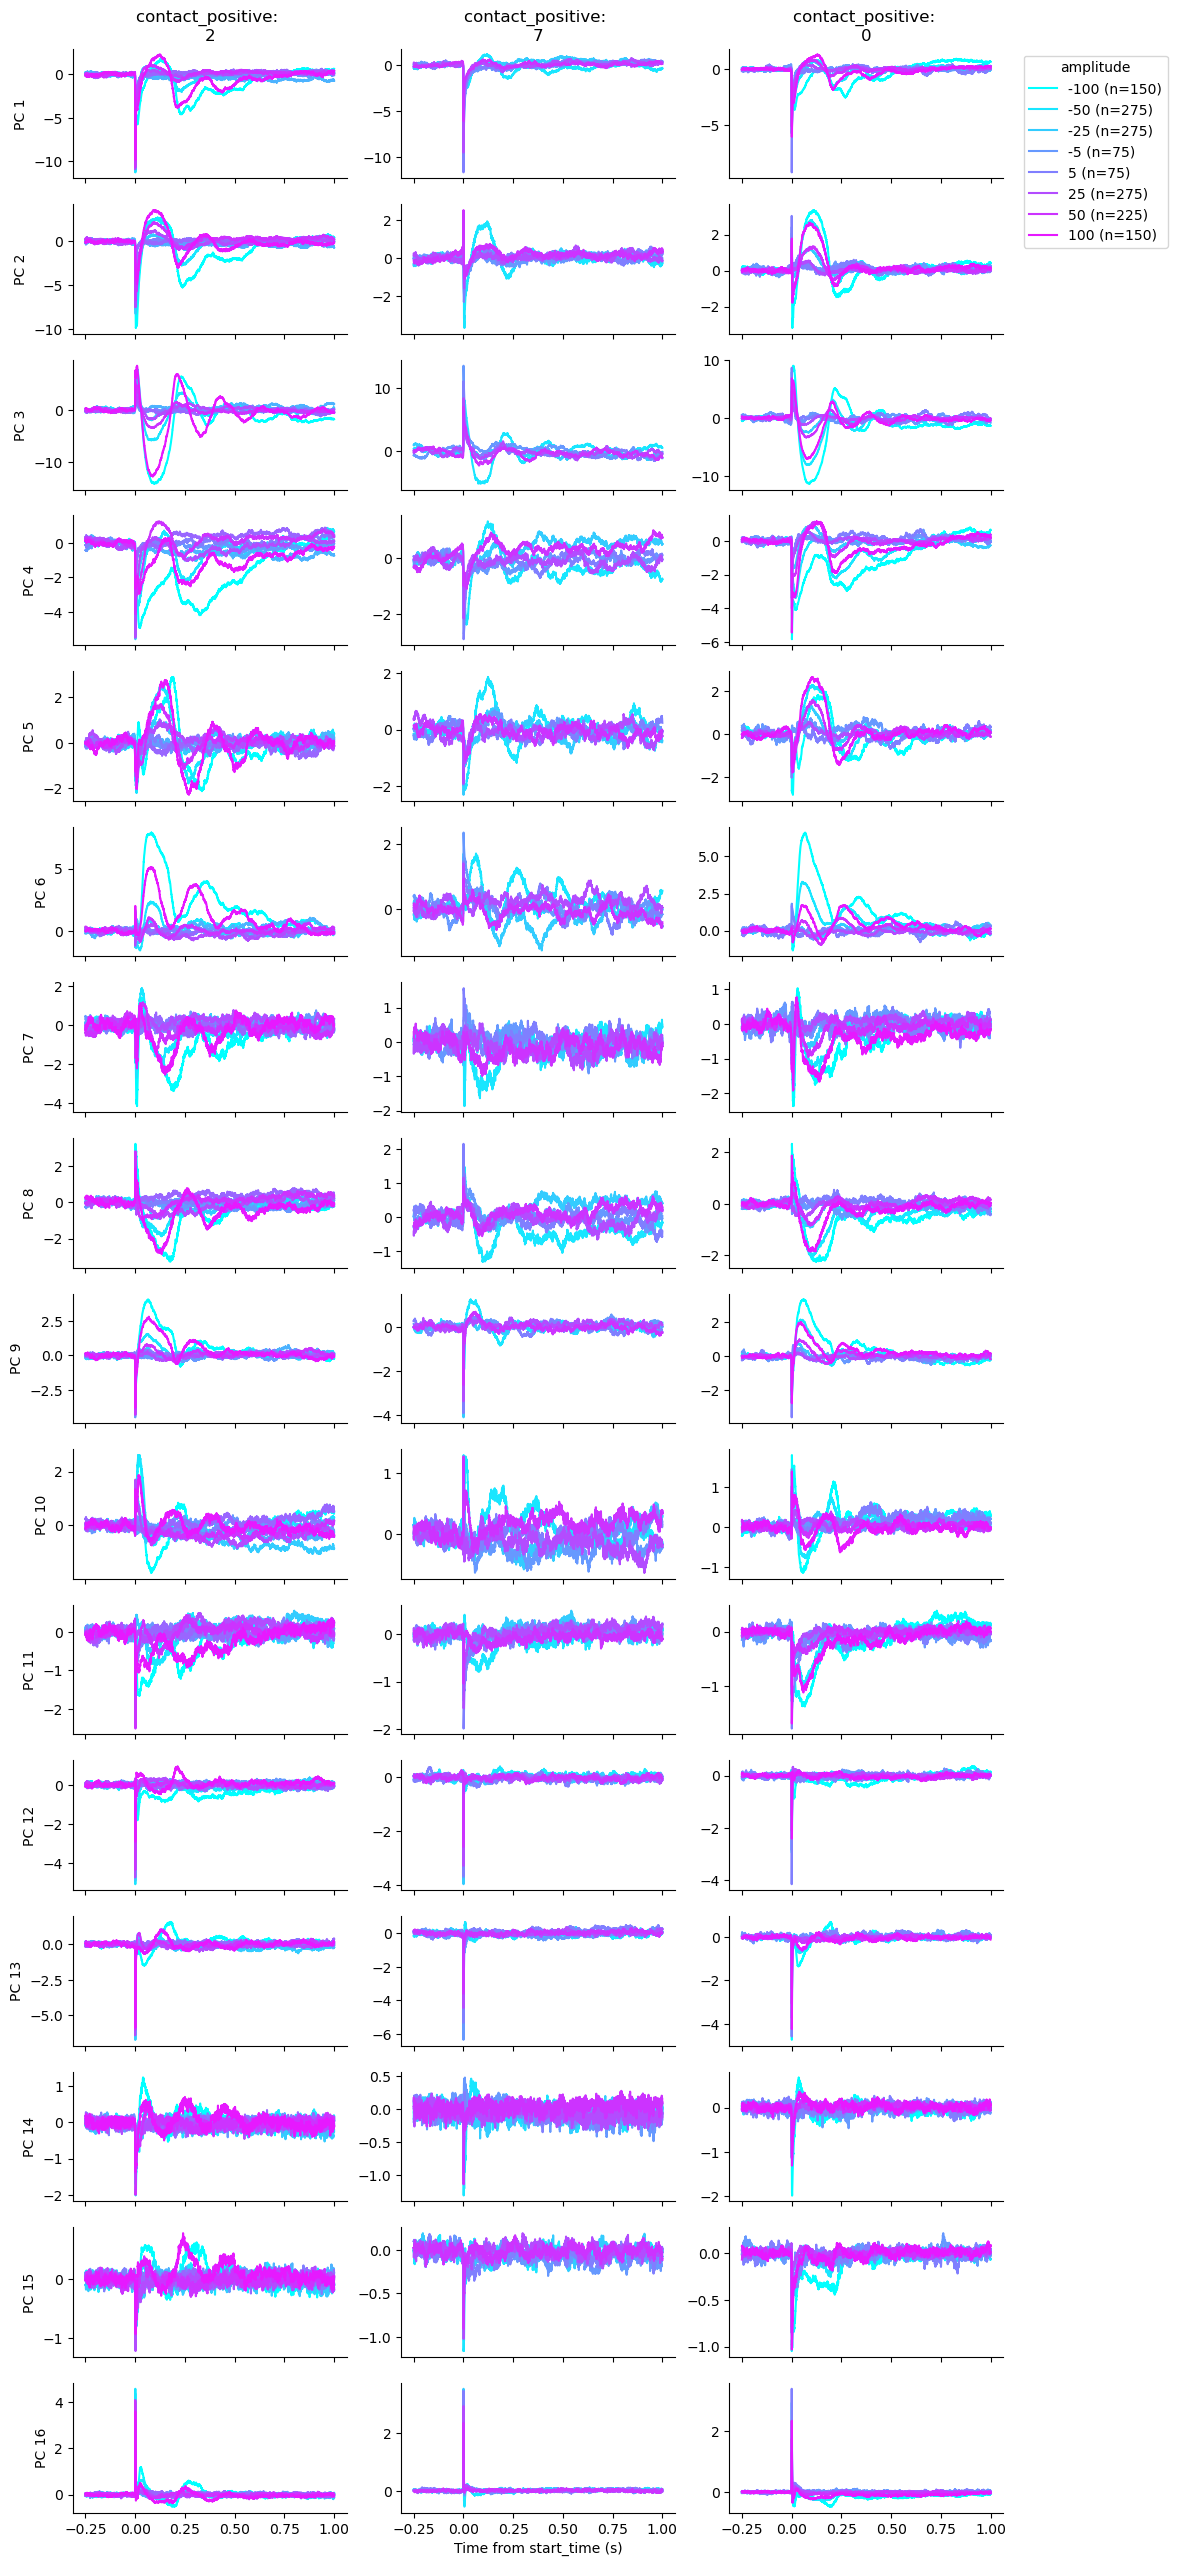

In [48]:
top_feature = "contact_positive"
sub_feature = "amplitude"
mark = "start_time"
window = (-.25,1)
# window = (-.025,.05)
# window = (-.03,.05)
# window = (-.01,.01)

sub_pre_stim = True

top_groups = event_df[top_feature].unique()
sub_groups = event_df[sub_feature].unique()
sub_groups = np.sort(sub_groups)

n_pc = 16
fig, ax_list = plt.subplots(ncols = len(top_groups),nrows = n_pc,
                            sharex=True,
                            figsize=(4*len(top_groups),2*n_pc))

for i_finger, finger in enumerate(top_groups):
    df = event_df[event_df[top_feature] == finger]
    ax_list[0,i_finger].set_title(f"{top_feature}: \n{finger}")
    for i_dir, direction in enumerate(sub_groups):
        df_dir = df[df[sub_feature] == direction]
        if len(df_dir) == 0:
            continue
        result = analysis.alligned_response(df_dir[mark].values, window, pca=True)
        t_plot = np.linspace(window[0], window[1], result.shape[1])
        if sub_pre_stim:
            in_pre = (t_plot < 0)
            result_pre = result[:,in_pre,:].mean(axis=1, keepdims=True)
            result = result - result_pre

        mid = np.mean(result, axis=0)
        # low = np.percentile(result, 25, axis=0)
        # high = np.percentile(result, 75, axis=0)
        color = i_dir / len(sub_groups)
        # color = plt.cm.tab10(color)
        color = plt.cm.cool(color)

        for i_pc in range(n_pc):
            a = ax_list[i_pc,i_finger]
            # a.fill_between(t_plot, low[:,i_pc], high[:,i_pc], color=color, alpha=0.3)
            label = f"{direction} (n={len(df_dir)})"
            a.plot(t_plot, mid[:,i_pc], color=color, label=label)
            if i_finger == 0:
                a.set_ylabel(f"PC {i_pc+1}")
            a.spines[['top', 'right']].set_visible(False)

ax_list[0,-1].legend(title=sub_feature, bbox_to_anchor=(1.05, 1), loc='upper left')
ax_list[-1, 1]. set_xlabel(f"Time from {mark} (s)")

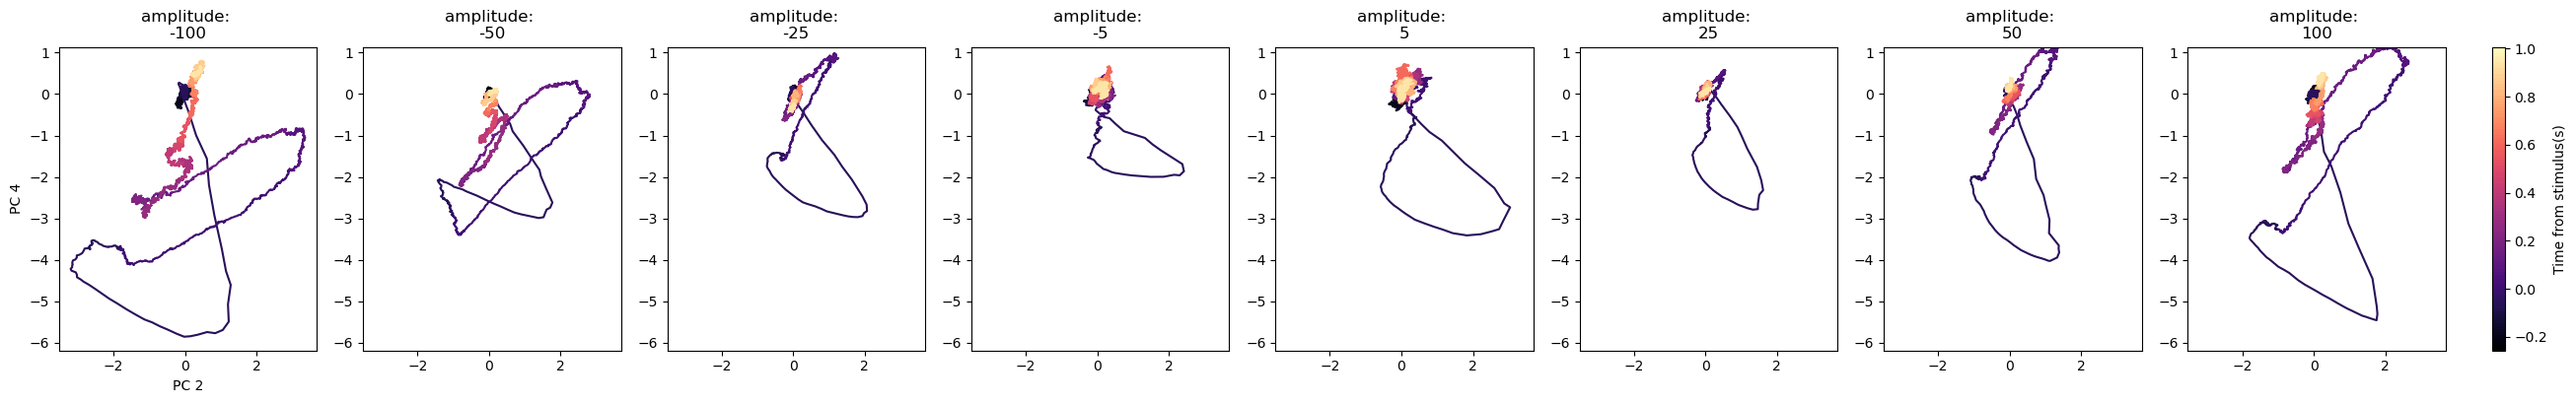

In [49]:
top_feature = "contact_positive"
sub_feature = "amplitude"
mark = "start_time"
window = (-.25,1)
window_plot = (.01, .5)
window_plot = window
bins = 20

pc_pair = (1,2)
pc_pair = 1,5
pc_pair = 1,3
# pc_pair = 9,10
# pc_pair = 4,5
df = event_df[event_df[top_feature] == 0]


sub_groups = df[sub_feature].unique()
sub_groups = np.sort(sub_groups)
fig, ax_list = plt.subplots(ncols = len(sub_groups)+1, figsize=(4*len(sub_groups),4),
                            # sharex=True, sharey=True,
                            width_ratios=[1]*len(sub_groups)+[0.05])


for i_dir, direction in enumerate(sub_groups):
    df_dir = df[df[sub_feature] == direction]
    if len(df_dir) == 0:
        continue
    result = analysis.alligned_response(df_dir[mark].values, window, pca=True)
    t_plot = np.linspace(window[0], window[1], result.shape[1])
    if sub_pre_stim:
        in_pre = (t_plot < 0)
        result_pre = result[:,in_pre,:].mean(axis=1, keepdims=True)
        result = result - result_pre

    mid = np.mean(result, axis=0)
    # low = np.percentile(result, 25, axis=0)
    # high = np.percentile(result, 75, axis=0)
    # color = i_dir / len(sub_groups)
    # # color = plt.cm.tab10(color)
    # color = plt.cm.magma(color)
    ax = ax_list[i_dir]

    ind_plot = np.where((t_plot >= window_plot[0]) & (t_plot <= window_plot[1]))[0]
    ind_ranges = np.linspace(ind_plot[0], ind_plot[-1], bins, dtype=int)
    for n_ii, ii in enumerate(range(len(ind_ranges)-1)):
        ind_plot = np.arange(ind_ranges[ii], ind_ranges[ii+1])
        color = plt.cm.magma(n_ii / (len(ind_ranges)-1))
        ax.plot(mid[ind_plot,pc_pair[0]],mid[ind_plot,pc_pair[1]], color=color, label=f"{direction} (n={len(df_dir)})",
                )
    ax.set_title(f"{sub_feature}: \n{direction}")

ylim = ax_list[0].get_ylim()
xlim = ax_list[0].get_xlim()
for a in ax_list[:-1]:
    a.set_ylim(ylim)
    a.set_xlim(xlim)

ax_list[0].set_xlabel(f"PC {pc_pair[0]+1}")
ax_list[0].set_ylabel(f"PC {pc_pair[1]+1}")
cb = plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.magma), orientation='vertical', label='Time from stimulus(s)',
                  cax=ax_list[-1], values=np.linspace(window[0], window[1], 100))

Text(0.5, 0.98, 'contact_positive: 0')

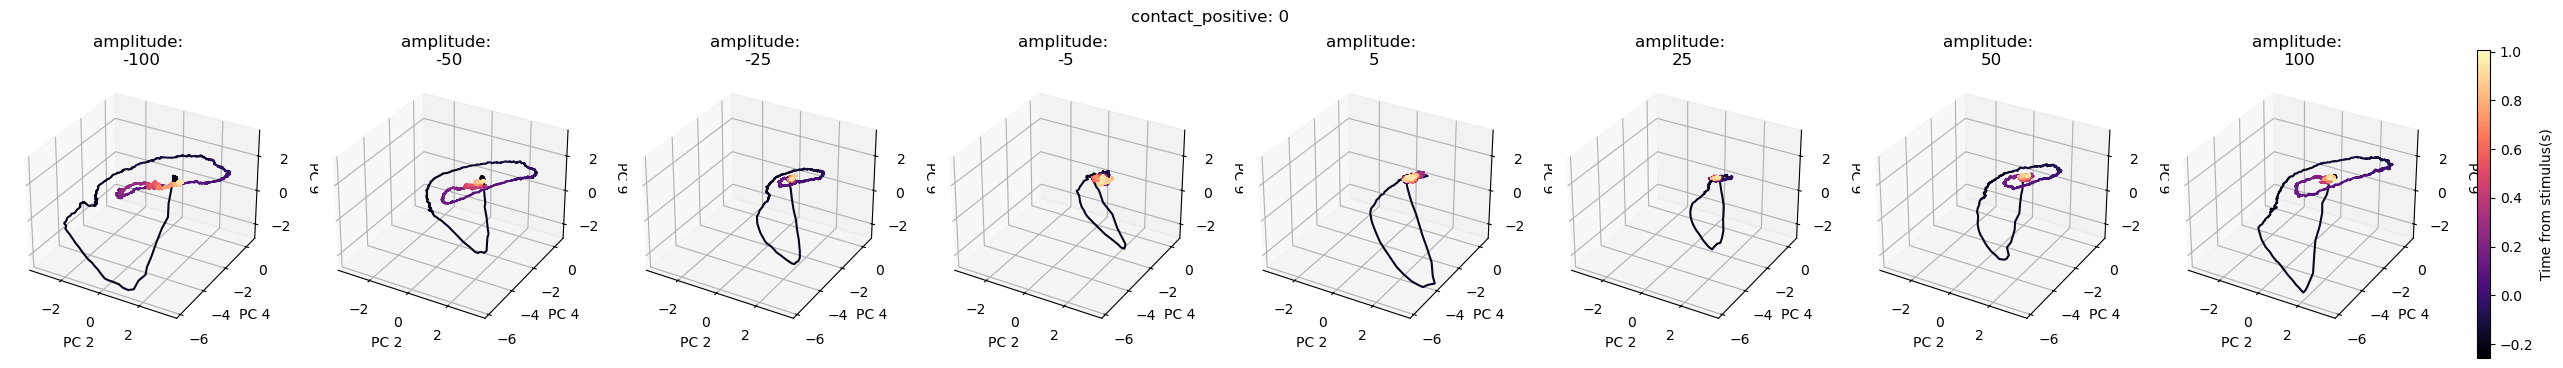

In [47]:
top_feature = "contact_positive"
sub_feature = "amplitude"
mark = "start_time"
window = (-.25,1)
window_plot = (.01, .5)
window_plot = (-.05, .75)
bins = 20

pc_pair = (1,2)
pc_pair = 1,3,8
# pc_pair = 9,10
# pc_pair = 4,5
df = event_df[event_df[top_feature] == 0]


sub_groups = df[sub_feature].unique()
sub_groups = np.sort(sub_groups)
# fig, ax_list = plt.subplots(ncols = len(sub_groups)+1, figsize=(4*len(sub_groups),4),
#                             # sharex=True, sharey=True,
#                             width_ratios=[1]*len(sub_groups)+[0.05])
fig = plt.figure(figsize=(4*len(sub_groups),4))
gs = fig.add_gridspec(1, len(sub_groups)+1, width_ratios=[1]*len(sub_groups)+[0.05])
ax_list = [
    fig.add_subplot(gs[0, i], projection="3d")
    for i in range(len(sub_groups))
] + [fig.add_subplot(gs[0, -1])]

for i_dir, direction in enumerate(sub_groups):

    df_dir = df[df[sub_feature] == direction]
    if len(df_dir) == 0:
        continue
    result = analysis.alligned_response(df_dir[mark].values, window, pca=True)
    t_plot = np.linspace(window[0], window[1], result.shape[1])
    if sub_pre_stim:
        in_pre = (t_plot < 0)
        result_pre = result[:,in_pre,:].mean(axis=1, keepdims=True)
        result = result - result_pre

    mid = np.mean(result, axis=0)
    # low = np.percentile(result, 25, axis=0)
    # high = np.percentile(result, 75, axis=0)
    # color = i_dir / len(sub_groups)
    # # color = plt.cm.tab10(color)
    # color = plt.cm.magma(color)
    ax = ax_list[i_dir]

    ind_plot = np.where((t_plot >= window_plot[0]) & (t_plot <= window_plot[1]))[0]
    ind_ranges = np.linspace(ind_plot[0], ind_plot[-1], bins, dtype=int)
    for n_ii, ii in enumerate(range(len(ind_ranges)-1)):
        ind_plot = np.arange(ind_ranges[ii], ind_ranges[ii+1])
        color = plt.cm.magma(n_ii / (len(ind_ranges)-1))
        ax.plot(mid[ind_plot,pc_pair[0]],mid[ind_plot,pc_pair[1]], mid[ind_plot,pc_pair[2]],
                color=color, label=f"{direction} (n={len(df_dir)})",
                )
    ax.set_title(f"{sub_feature}: \n{direction}")
    ax.set_xlabel(f"PC {pc_pair[0]+1}")
    ax.set_ylabel(f"PC {pc_pair[1]+1}")
    ax.set_zlabel(f"PC {pc_pair[2]+1}", rotation=270)

ylim = ax_list[0].get_ylim()
xlim = ax_list[0].get_xlim()
zlim = ax_list[0].get_zlim()
for a in ax_list[:-1]:
    a.set_ylim(ylim)
    a.set_xlim(xlim)
    a.set_zlim(zlim)

ax_list[0].set_xlabel(f"PC {pc_pair[0]+1}")
ax_list[0].set_ylabel(f"PC {pc_pair[1]+1}")
cb = plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.magma), orientation='vertical', label='Time from stimulus(s)',
                  cax=ax_list[-1], values=np.linspace(window[0], window[1], 100))
fig.suptitle(f"{top_feature}: {finger}")

In [22]:
dataset_df

,dandiset_id,dandi_path,publication_source,behavioral_or_experimental_feature_to_compare,number_of_units,brain_regions_of_recording,why_chosen,event_object_path,event_object_id,event_feature_name
19,689,sub-H19/sub-H19_ses-H19-2019-10-31-17-44-38-Di...,"Li et al., Nature (2022), https://doi.org/10.1...",Pavlovian discrimination trial type and valenc...,64,Amygdala (asset electrode location unspecified),Single-system aversive and appetitive learning...,/intervals/trials,b2a7b630-c4b5-4592-a6f9-720a0b3ec528,start_time


In [7]:
dataset_df.publication_source.values[0]

'https://doi.org/10.1016/j.celrep.2026.117420'

In [35]:
import yaml
yaml_path = model_dir / "metrics.yaml"
metrics = yaml.safe_load(open(yaml_path, "r"))
metrics

{'dimensions': 16,
 'mua_rate': 2062.1848448642604,
 'n_units': 785,
 'training_time': 6742.4376854896545}

In [42]:
# unit_df = nwbfile.units.to_dataframe()
unit_df.brain_reg.unique()

array(['Postsubiculum', 'corpus callosum, posterior forceps',
       'dorsal hippocampal commissure', 'Primary visual area, layer 6a',
       'Primary visual area, layer 5', 'Primary visual area, layer 4',
       'Primary visual area, layer 2/3', 'Field CA1', 'optic radiation',
       'Primary visual area, layer 6b', 'Lateral visual area, layer 6a',
       'posteromedial visual area, layer 2/3',
       'posteromedial visual area, layer 1'], dtype=object)

In [53]:
nwbfile.subject

subject pynwb.file.Subject at 0x140299207485392
Fields:
  age: P83D
  age__reference: birth
  description: craniotomy
  sex: F
  species: Mus musculus
  strain: C57/B6
  subject_id: jlh31